# Volcanicus tutorial

`volcanicus` wraps per-volcano deformation/residual measurements — one row per date/direction, one column per distance bin — in a `Volcano` object, taking care of dtype normalization and offering quick summary, statistics and plotting helpers on top of the pandas stack.

This notebook walks through:

1. Loading a bundled dataset
2. Inspecting the normalized `DataFrame`
3. Summarizing measurements with `Volcano.radial_profile()`
4. Plotting with the `.plots` accessor
5. Computing statistics with the `.stats` accessor


In [1]:
import volcanicus

volcanicus.__all__

['Volcano',
 'normalize_dataframe',
 'read_csv',
 'PlotAccessor',
 'StatsAccessor',
 'datasets']

## 1. Loading a bundled dataset

`volcanicus.datasets` ships a few example datasets, loadable by name.

In [2]:
volcanicus.datasets.available()

['etna']

In [3]:
etna = volcanicus.datasets.load("etna")
etna

Volcano(name='etna', rows=790, cols=34)

You can also build a `Volcano` from your own CSV file, either with the classmethod or the module-level shortcut:

```python
volcano = volcanicus.Volcano.from_csv("measurements.csv", volcano_name="Copahue")
volcano = volcanicus.read_csv("measurements.csv", volcano_name="Copahue")
```

The CSV is expected to have a `date` column, `center_lat`/`center_long`, a `direction` column, and one column per distance bin (everything else).

## 2. Inspecting the normalized `DataFrame`

`Volcano.__init__` normalizes dtypes on the way in: `date` is parsed as `datetime`, `center_lat`/`center_long` and the distance-bin columns as numeric, and `direction` as a category. `.dataframe` always returns a copy, so the internal state can't be mutated from the outside.

In [4]:
etna.dataframe.head()

,date,center_lat,center_long,direction,15m,45m,75m,105m,135m,165m,...,615m,645m,675m,705m,735m,765m,795m,825m,855m,885m
0,2000-07-26,37.7464,15.0073,E,0.5395,0.3623,0.2461,0.1103,0.0178,0.0227,...,-0.0776,-0.0789,-0.0773,-0.0733,-0.0540,-0.0543,-0.0657,-0.0684,-0.0702,-0.0641
1,2000-07-26,37.7464,15.0073,N,0.3843,0.3879,0.2208,0.1241,0.0467,0.0497,...,-0.0723,-0.0681,-0.0634,-0.0360,-0.0302,-0.0392,-0.0149,0.0151,0.0206,0.0365
2,2000-07-26,37.7464,15.0073,NE,0.4063,0.4107,0.2132,0.0754,0.0157,-0.0163,...,0.0058,0.0070,-0.0138,0.0065,0.0084,-0.0098,-0.0328,-0.0284,-0.0433,-0.0394
3,2000-07-26,37.7464,15.0073,NO,NaN,0.2892,0.2235,0.1337,0.0978,0.0633,...,-0.0234,-0.0285,-0.0219,-0.0090,-0.0085,-0.0059,-0.0014,0.0028,0.0085,0.0322
4,2000-07-26,37.7464,15.0073,O,NaN,0.4206,0.3449,0.2232,0.1313,0.0506,...,-0.0110,-0.0126,0.0030,0.0102,0.0221,0.0279,0.0098,-0.0073,-0.0317,-0.0533


In [5]:
etna.dataframe.dtypes.head()

date           datetime64[us]
center_lat            float64
center_long           float64
direction            category
15m                   float64
dtype: object

## 3. Summarizing measurements

`radial_profile()` averages the measurements over dates, per direction, producing one row per direction with the mean of every distance bin — the spatial curve, residual vs. distance.

`temporal_profile()` is its mirror: it averages over distance bins instead, producing one row per date with one column per direction — the temporal curve, residual vs. date.

In [6]:
etna.radial_profile().iloc[:, :6]

,15m,45m,75m,105m,135m,165m
direction,,,,,,
E,0.371373,0.272800,0.189716,0.142984,0.116166,0.094440
N,0.247392,0.196262,0.127873,0.093690,0.058153,0.042932
NE,0.300232,0.277657,0.195775,0.142963,0.111649,0.089847
NO,0.275927,0.219451,0.171200,0.105266,0.094334,0.088870
O,0.356040,0.308743,0.204983,0.138558,0.120303,0.096544
S,0.289061,0.284103,0.210740,0.165876,0.126052,0.100131
SE,0.317587,0.293560,0.219379,0.180023,0.152292,0.123560
SO,0.411945,0.296544,0.232454,0.164477,0.131767,0.103760


In [7]:
etna.temporal_profile().iloc[:5, :6]

direction,E,N,NE,NO,O,S
date,,,,,,
2000-07-26,0.056967,0.029077,0.045677,0.029207,0.048990,0.044527
2001-06-27,0.107037,0.004512,0.063200,0.055097,0.032279,0.059103
2001-07-13,0.049444,0.033950,0.179943,0.108969,0.096848,0.013970
2001-07-29,0.053738,0.053427,0.082808,0.050145,0.059545,0.782550
2001-08-30,0.055833,0.022893,0.059041,0.065020,0.000755,0.065410


## 4. Plotting with `.plots`

The `.plots` accessor follows the same pattern used across the library (`AccessorABC`): it's callable, dispatching to the method named `kind` (`"radial_profile"` by default), and its methods can also be called directly.

<Axes: title={'center': 'etna: residual vs. distance by direction'}, xlabel='Distance (m)', ylabel='Residual'>

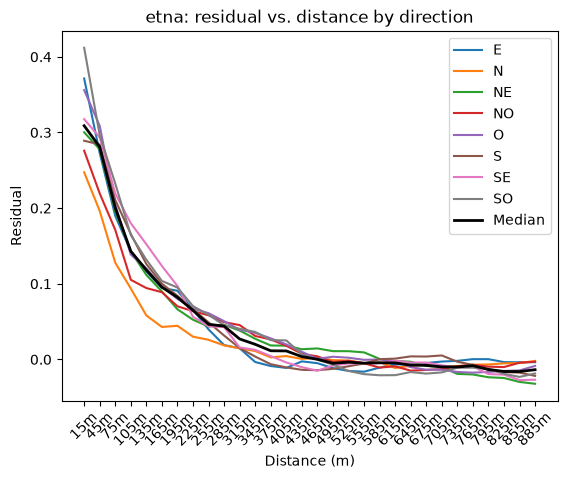

In [8]:
%matplotlib inline

etna.plots.radial_profile()

The per-direction lines show `std` error bars when `std=True`, and the aggregate median line can be turned off with `mean=False`:

<Axes: title={'center': 'etna: residual vs. distance by direction'}, xlabel='Distance (m)', ylabel='Residual'>

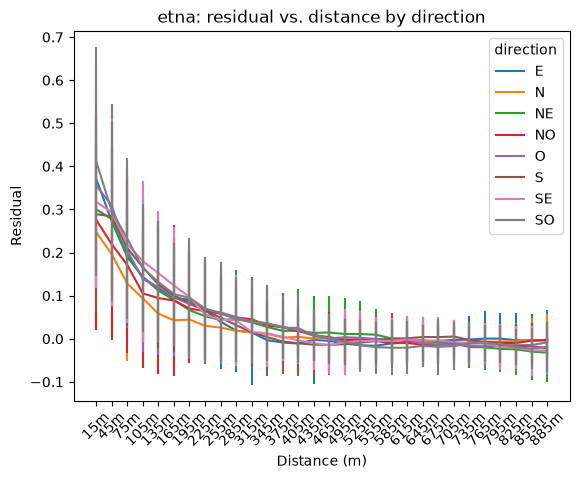

In [9]:
etna.plots.radial_profile(std=True, mean=False)

Since `PlotAccessor` is callable, the same plot can be produced with the default kind:

```python
etna.plots()  # same as etna.plots.radial_profile()
etna.plots("radial_profile", mean=False)
```


`temporal_profile()` is the plot's temporal mirror: same two-layer plot (one line per direction, plus an aggregate median line), but with `date` on the x-axis. Error bars on the per-direction lines come from the spread across distance bins at each date, instead of across dates at each distance bin.

<Axes: title={'center': 'etna: residual vs. date by direction'}, xlabel='Date', ylabel='Residual'>

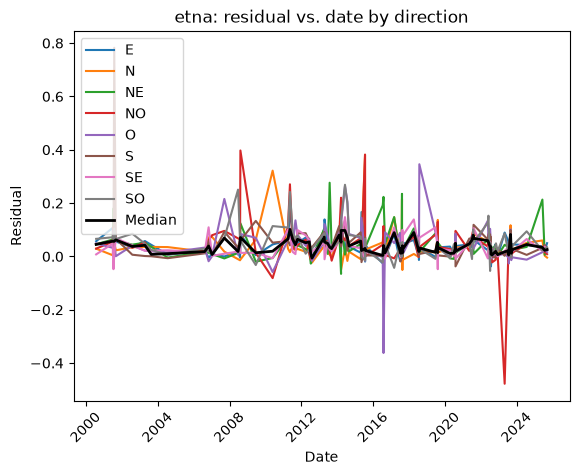

In [10]:
etna.plots.temporal_profile()

## 5. Statistics with `.stats`

The `.stats` accessor exposes a whitelist of pandas statistical methods (`describe`, `mean`, `median`, `std`, `var`, `cov`, `kurtosis`, `sem`, `skew`, `min`, `max`, `quantile`, `pct_change`), plus `corr` and `mad`. Every one of them takes a mandatory first parameter, `groupby`, which can only be `"date"` or `"direction"` — the measurements are grouped by that column before the statistic is computed.

In [11]:
etna.stats.mean(groupby="direction").iloc[:, :6]

,15m,45m,75m,105m,135m,165m
direction,,,,,,
E,0.371373,0.272800,0.189716,0.142984,0.116166,0.094440
N,0.247392,0.196262,0.127873,0.093690,0.058153,0.042932
NE,0.300232,0.277657,0.195775,0.142963,0.111649,0.089847
NO,0.275927,0.219451,0.171200,0.105266,0.094334,0.088870
O,0.356040,0.308743,0.204983,0.138558,0.120303,0.096544
S,0.289061,0.284103,0.210740,0.165876,0.126052,0.100131
SE,0.317587,0.293560,0.219379,0.180023,0.152292,0.123560
SO,0.411945,0.296544,0.232454,0.164477,0.131767,0.103760


In [12]:
etna.stats.describe(groupby="direction").iloc[:, :3]

15m        45m        75m
direction                                       
E         count  60.000000  78.000000  74.000000
          mean    0.371373   0.272800   0.189716
          std     0.211283   0.169257   0.155733
          min    -0.001800   0.006600  -0.106400
          25%     0.213200   0.150800   0.087950
...                    ...        ...        ...
SO        min    -0.053100  -0.084300  -0.114600
          25%     0.176400   0.133100   0.108300
          50%     0.440300   0.268800   0.215700
          75%     0.552800   0.410150   0.351400
          max     1.123200   1.094300   1.046800

[64 rows x 3 columns]

`.stats` is also callable, dispatching to `_default_kind` (`"describe"`) when no kind is given:

In [13]:
etna.stats(groupby="date").iloc[:, :3]

15m       45m       75m
date                                          
2000-07-26 count  5.000000  8.000000  8.000000
           mean   0.431300  0.342187  0.229075
           std    0.102094  0.081838  0.069947
           min    0.298100  0.197800  0.115800
           25%    0.384300  0.283050  0.203325
...                    ...       ...       ...
2025-09-08 min    0.061000  0.030700  0.029800
           25%    0.071275  0.090575  0.076925
           50%    0.091900  0.108800  0.100250
           75%    0.141850  0.167675  0.148700
           max    0.240100  0.215900  0.200300

[792 rows x 3 columns]

`corr` and `mad` are hand-written (not simple pandas passthroughs), but follow the same `groupby`-first convention:

In [14]:
etna.stats.corr("direction").head()

15m       45m       75m      105m      135m      165m  \
direction                                                                    
E         15m   1.000000  0.900073  0.657493  0.463540  0.285467  0.102610   
          45m   0.900073  1.000000  0.915299  0.768541  0.612158  0.358085   
          75m   0.657493  0.915299  1.000000  0.941758  0.810014  0.548644   
          105m  0.463540  0.768541  0.941758  1.000000  0.940849  0.699488   
          135m  0.285467  0.612158  0.810014  0.940849  1.000000  0.858676   

                    195m      225m      255m      285m  ...      615m  \
direction                                               ...             
E         15m   0.143041  0.162428  0.120180  0.104504  ... -0.054862   
          45m   0.270977  0.270242  0.193872  0.191427  ... -0.089932   
          75m   0.401549  0.415204  0.354021  0.361589  ... -0.166751   
          105m  0.546809  0.522030  0.466023  0.481794  ... -0.199905   
          135m  0.727266  0.689591  0.587109  0.580167  ... -0.274565   

                    645m      675m      705m      735m      765m      795m  \
direction                                                                    
E         15m   0.032821  0.121826  0.102161  0.076119  0.021717 -0.040412   
          45m  -0.058808 -0.012038 -0.043347 -0.031938 -0.080356 -0.174555   
          75m  -0.176869 -0.102792 -0.138489 -0.098711 -0.139087 -0.317831   
          105m -0.228842 -0.136280 -0.193662 -0.184512 -0.233374 -0.370236   
          135m -0.294715 -0.192386 -0.262936 -0.267899 -0.266824 -0.383187   

                    825m      855m      885m  
direction                                     
E         15m  -0.112276 -0.058524 -0.093213  
          45m  -0.232933 -0.160331 -0.156072  
          75m  -0.330994 -0.215864 -0.185539  
          105m -0.361565 -0.295145 -0.168414  
          135m -0.409357 -0.325055 -0.123832  

[5 rows x 30 columns]

In [15]:
etna.stats.mad("direction").iloc[:, :6]

,15m,45m,75m,105m,135m,165m
direction,,,,,,
E,0.171704,0.129572,0.117019,0.104063,0.092990,0.083020
N,0.162247,0.145391,0.129752,0.107947,0.096558,0.082095
NE,0.146060,0.151527,0.135230,0.119106,0.108107,0.095909
NO,0.191915,0.168161,0.151662,0.121246,0.119316,0.120703
O,0.199089,0.186395,0.136946,0.122444,0.110269,0.092950
S,0.169714,0.170882,0.146963,0.131494,0.110001,0.098111
SE,0.152237,0.173170,0.143492,0.137556,0.107093,0.092962
SO,0.210516,0.159998,0.138810,0.111409,0.099230,0.085281


Passing anything other than `"date"` or `"direction"` raises a clear error:

In [16]:
try:
    etna.stats.mean(groupby="center_lat")
except ValueError as e:
    print("ValueError:", e)

ValueError: 'groupby' must be one of ('date', 'direction'), found 'center_lat'


## 6. Missing values

Real deformation datasets have gaps. `has_missing` is a quick check, and `missing_report()` summarizes how missing values are distributed across dates.

In [17]:
etna.has_missing

True

In [18]:
etna.missing_report()

n_missing                4315.000000
n_dates                    99.000000
n_dates_with_missing       99.000000
missing_per_date_min        3.000000
missing_per_date_max      481.000000
missing_per_date_mean      43.585859
dtype: float64

## Next steps

- [README.md](../README.md) for installation and a quick reference.
- `volcanicus.datasets.available()` for the full list of bundled datasets.
- `volcanicus.utils.AccessorABC` if you want to add your own accessor following the same `volcano.<accessor>(kind, **kwargs)` pattern used by `.plots` and `.stats`.
